In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import glob

# 找到所有CSV文件
path = '/content/drive/MyDrive/idx_dataset/'
files = glob.glob(path + 'CRMLSSold*.csv')

# 合并成一个dataframe
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(df.shape)
df.head()

/tmp/ipykernel_29762/1928895754.py:9: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
/tmp/ipykernel_29762/1928895754.py:9: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


(189608, 78)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,NaN,1807.0,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,NaN,14253.0,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN


In [4]:
df = df[(df['PropertyType'] == 'Residential') &
        (df['PropertySubType'] == 'SingleFamilyResidence')]
print(df.shape)

(95196, 78)


In [5]:
# 看有哪些列
print(df.columns.tolist())

# 看基本统计
df.describe()

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,9.499300e+04,9.519600e+04,9.519600e+04,95184.000000,95184.000000,95147.000000,9.519600e+04,95196.000000,0.0,0.0,...,0.0,681.000000,0.0,85168.000000,9.356700e+04,57887.000000,91502.000000,67604.000000,9.355800e+04,0.0
mean,1.374670e+06,1.137981e+09,1.343097e+06,34.730261,-118.586368,2055.066906,1.269466e+06,41.073175,NaN,NaN,...,NaN,65.731278,NaN,1.354523,1.843502e+04,2.259022,2.017644,107.880651,4.495698e+05,NaN
std,7.793322e+06,1.747771e+07,7.764911e+06,1.776839,3.366201,1041.751901,1.557639e+06,55.391498,NaN,NaN,...,NaN,275.204827,NaN,0.478371,1.767859e+05,1.437886,3.980500,351.112675,1.945697e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,-22.863239,-124.175789,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.350000e+05,1.126016e+09,6.242055e+05,33.758188,-119.152458,1389.000000,6.250000e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.400000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.144632e+09,8.900000e+05,34.082716,-118.025502,1825.000000,8.950000e+05,20.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.062000e+03,3.000000,2.000000,0.000000,7.280000e+03,NaN
75%,1.449000e+06,1.151952e+09,1.425000e+06,34.817881,-117.256665,2450.000000,1.399900e+06,53.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.936000e+03,3.000000,2.000000,133.000000,1.045400e+04,NaN
max,1.302000e+09,1.171669e+09,9.895000e+08,43.784440,120.432670,31068.000000,7.500000e+07,2177.000000,NaN,NaN,...,NaN,3490.000000,NaN,2.000000,3.164242e+07,44.000000,600.000000,20712.000000,1.938943e+09,NaN


In [6]:
print(df.columns.tolist())

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractStatusChangeDate', 'ElementarySchoolDist

In [8]:
df = df[(df['PropertyType'] == 'Residential') &
        (df['PropertySubType'] == 'SingleFamilyResidence')]
print(df.shape)

(95196, 78)


去掉异常值后数据量: (88626, 78)


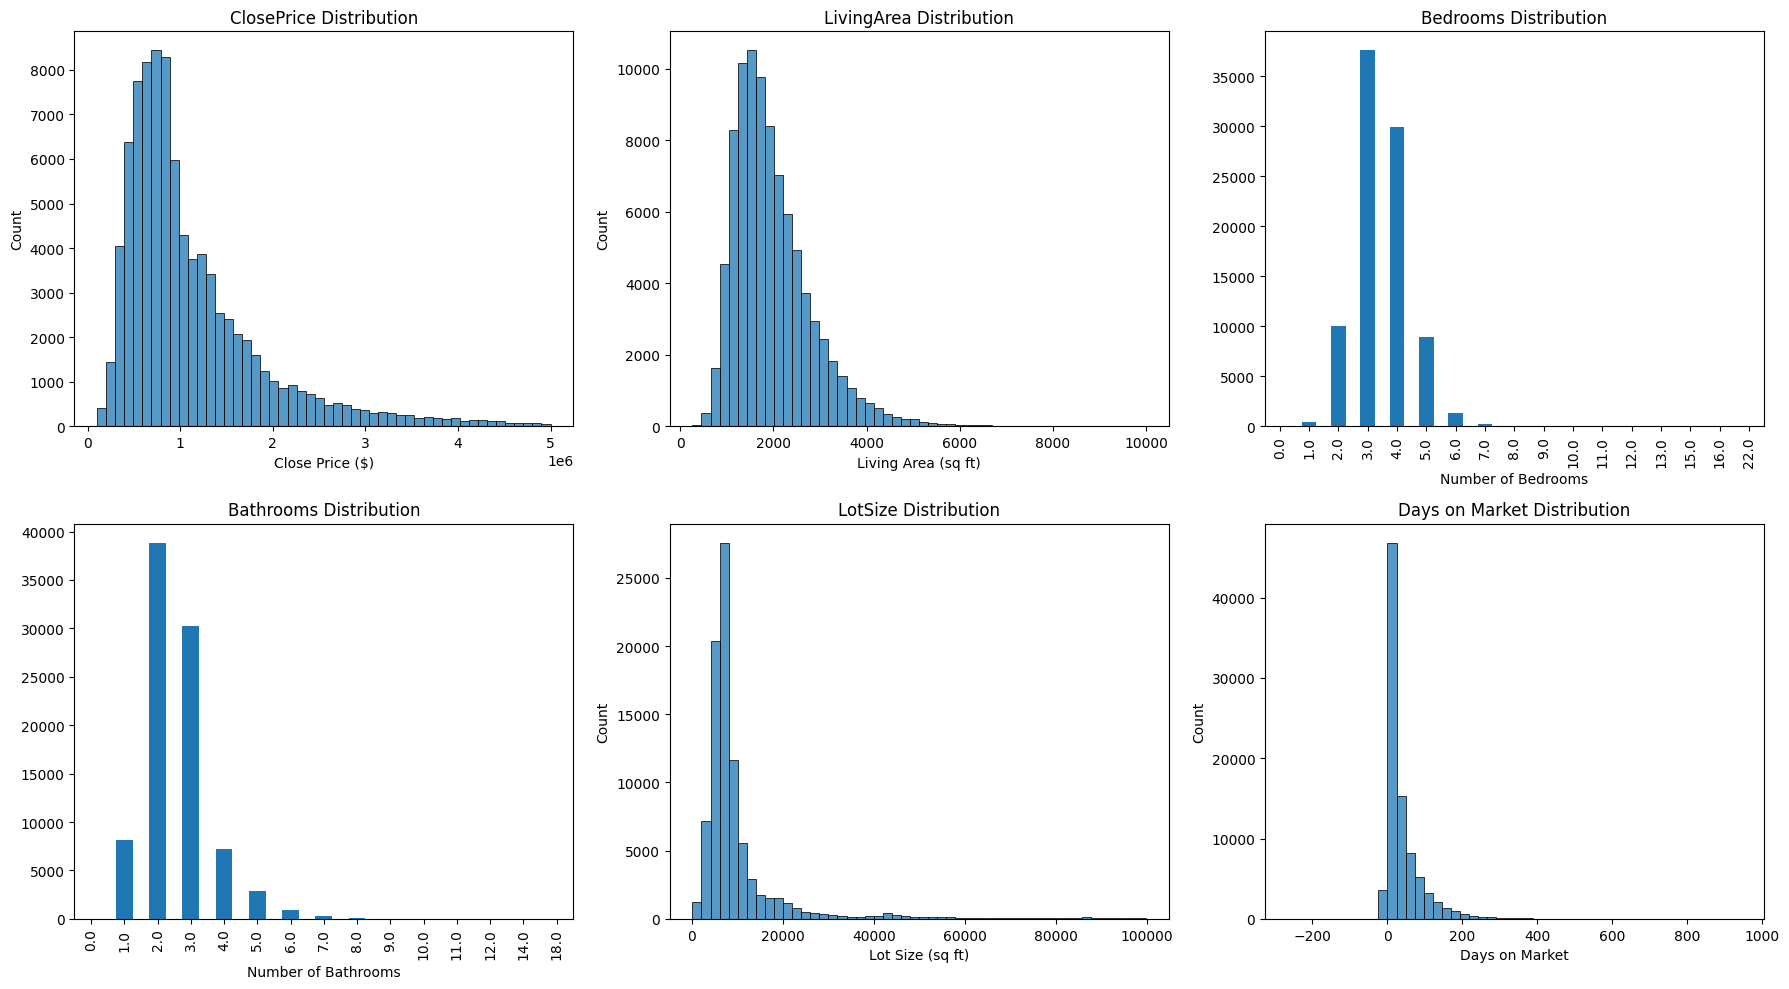

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df[
    (df['ClosePrice'] > 100000) & (df['ClosePrice'] < 5000000) &
    (df['LivingArea'] > 200) & (df['LivingArea'] < 10000) &
    (df['LotSizeSquareFeet'] > 100) & (df['LotSizeSquareFeet'] < 100000)
]
print(f'去掉异常值后数据量: {df_clean.shape}')

# 画分布图
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ClosePrice
sns.histplot(df_clean['ClosePrice'].dropna(), bins=50, ax=axes[0,0])
axes[0,0].set_title('ClosePrice Distribution')
axes[0,0].set_xlabel('Close Price ($)')

# LivingArea
sns.histplot(df_clean['LivingArea'].dropna(), bins=50, ax=axes[0,1])
axes[0,1].set_title('LivingArea Distribution')
axes[0,1].set_xlabel('Living Area (sq ft)')

# Bedrooms
df_clean['BedroomsTotal'].value_counts().sort_index().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Bedrooms Distribution')
axes[0,2].set_xlabel('Number of Bedrooms')

# Bathrooms
df_clean['BathroomsTotalInteger'].value_counts().sort_index().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Bathrooms Distribution')
axes[1,0].set_xlabel('Number of Bathrooms')

# LotSize
sns.histplot(df_clean['LotSizeSquareFeet'].dropna(), bins=50, ax=axes[1,1])
axes[1,1].set_title('LotSize Distribution')
axes[1,1].set_xlabel('Lot Size (sq ft)')

# DaysOnMarket
sns.histplot(df_clean['DaysOnMarket'].dropna(), bins=50, ax=axes[1,2])
axes[1,2].set_title('Days on Market Distribution')
axes[1,2].set_xlabel('Days on Market')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

In [20]:
!pwd
!ls

/content/idx-exchange-project
idx_project.pynb  README.md


In [21]:
!git status

On branch main
Your branch is based on 'origin/main', but the upstream is gone.
  (use "git branch --unset-upstream" to fixup)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   idx_project.pynb

no changes added to commit (use "git add" and/or "git commit -a")


In [48]:
%cd /content
!rm -rf idx-exchange-project

/content


In [47]:
# 1. 挂载Google Drive（如果还没挂载）
from google.colab import drive
drive.mount('/content/drive')

# 2. 输入token（不会保存到文件）
import getpass
token = getpass.getpass("输入你的GitHub Token: ")

# 3. Clone repo
%cd /content
!git clone https://{token}@github.com/rongweishen63-blip/idx-exchange-project.git
%cd idx-exchange-project

# 4. 复制notebook
!cp "/content/drive/MyDrive/Colab Notebooks/idx_project.ipynb" .

# 5. Push
!git add .
!git commit -m "更新EDA"
!git push origin main

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
输入你的GitHub Token: ··········
/content
fatal: destination path 'idx-exchange-project' already exists and is not an empty directory.
/content/idx-exchange-project
[main 878eb18] 更新EDA
 2 files changed, 1 insertion(+), 2 deletions(-)
 delete mode 100644 idx_project.pynb
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 578 bytes | 578.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot cont